*Machine Learning Regression Project Continues*

*1.Import Required Libraries*

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


*2. Read the Dataset*

In [2]:
df=pd.read_csv("C:/Intel/Students.csv")
df.head()

,Unnamed: 0,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,0,GP,F,18,U,GT3,A,4,4,at_home,...,4,3,4,1,1,3,6,5,6,6
1,1,GP,F,17,U,GT3,T,1,1,at_home,...,5,3,3,1,1,3,4,5,5,6
2,2,GP,F,15,U,LE3,T,1,1,at_home,...,4,3,2,2,3,3,10,7,8,10
3,3,GP,F,15,U,GT3,T,4,2,health,...,3,2,2,1,1,5,2,15,14,15
4,4,GP,F,16,U,GT3,T,3,3,other,...,4,3,2,1,2,5,4,6,10,10


*Identifying Missing Values*

<Axes: xlabel='age', ylabel='G3'>

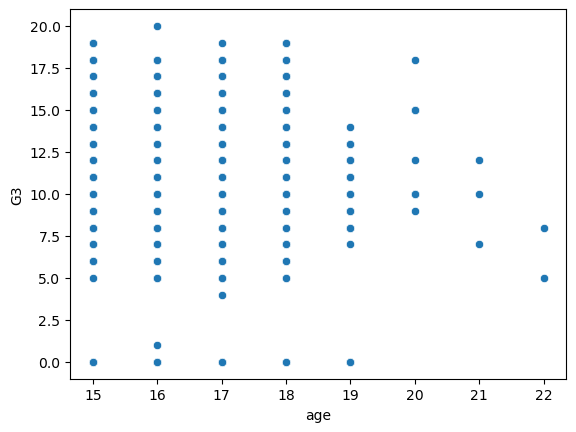

In [3]:
sns.scatterplot(data=df,x='age',y='G3')

*Filling Missing Values*

In [4]:
drop_index=df[(df['age']<20)&(df['G3']<2.5)].index

In [5]:
df=df.drop(drop_index,axis=0)

<Axes: xlabel='age', ylabel='G3'>

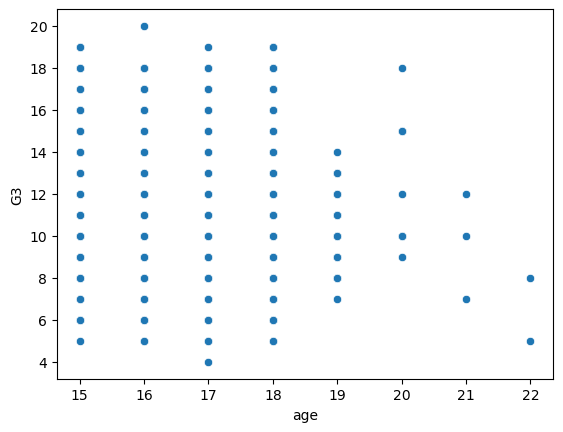

In [6]:
sns.scatterplot(data=df,x='age',y='G3')

*Filling Missing Values Continues*

In [7]:
drop_index1=df[(df['G1']<1)&(df['G3']>10)].index

<Axes: xlabel='G1', ylabel='G3'>

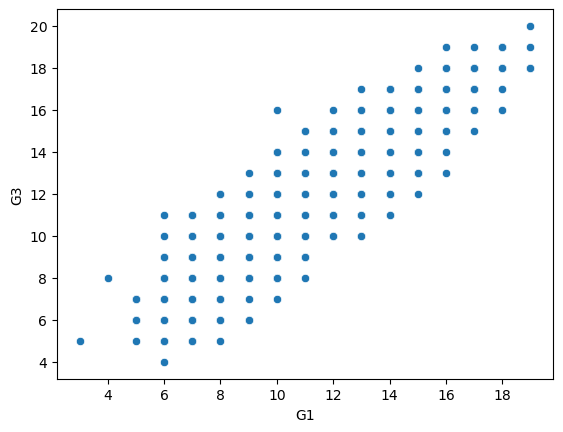

In [8]:
df=df.drop(drop_index1,axis=0)
sns.scatterplot(data=df,x='G1',y='G3')

*Filling Missing Values Continues*

<Axes: xlabel='absences', ylabel='G3'>

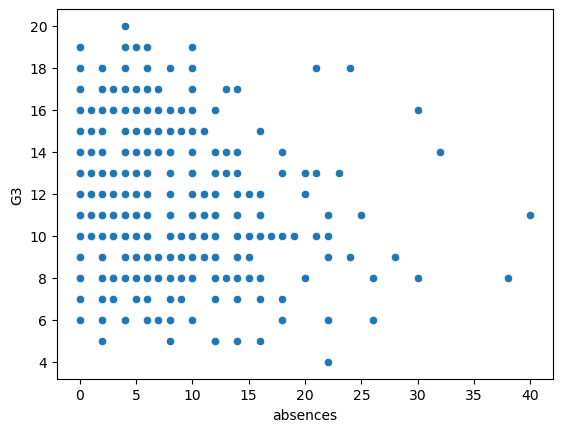

In [10]:
drop_index2=df[(df['absences']>50)&(df['G3']<12)].index
df=df.drop(drop_index2,axis=0)
sns.scatterplot(data=df,x='absences',y='G3')

*Converting Objects To Numeric Data*

In [12]:
object_df=df.select_dtypes(include=object)
object_df_dummies=pd.get_dummies(object_df,drop_first=True)
object_df_dummies

,school_MS,sex_M,address_U,famsize_LE3,Pstatus_T,Mjob_health,Mjob_other,Mjob_services,Mjob_teacher,Fjob_health,...,guardian_mother,guardian_other,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes
0,False,False,True,False,False,False,False,False,False,False,...,True,False,True,False,False,False,True,True,False,False
1,False,False,True,False,True,False,False,False,False,False,...,False,False,False,True,False,False,False,True,True,False
2,False,False,True,True,True,False,False,False,False,False,...,True,False,True,False,True,False,True,True,True,False
3,False,False,True,False,True,True,False,False,False,False,...,True,False,False,True,True,True,True,True,True,True
4,False,False,True,False,True,False,True,False,False,False,...,False,False,False,True,True,False,True,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1039,True,False,False,False,True,False,False,True,False,False,...,True,False,False,False,False,True,False,True,True,False
1040,True,False,True,True,True,False,False,False,True,False,...,True,False,False,True,False,False,True,True,True,False
1041,True,False,True,False,True,False,True,False,False,False,...,True,False,False,False,False,True,True,True,False,False
1042,True,True,True,True,True,False,False,True,False,False,...,True,False,False,False,False,False,False,True,True,False


In [13]:
object_df_dummies=pd.get_dummies(object_df,drop_first=True)
object_df_dummies

,school_MS,sex_M,address_U,famsize_LE3,Pstatus_T,Mjob_health,Mjob_other,Mjob_services,Mjob_teacher,Fjob_health,...,guardian_mother,guardian_other,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes
0,False,False,True,False,False,False,False,False,False,False,...,True,False,True,False,False,False,True,True,False,False
1,False,False,True,False,True,False,False,False,False,False,...,False,False,False,True,False,False,False,True,True,False
2,False,False,True,True,True,False,False,False,False,False,...,True,False,True,False,True,False,True,True,True,False
3,False,False,True,False,True,True,False,False,False,False,...,True,False,False,True,True,True,True,True,True,True
4,False,False,True,False,True,False,True,False,False,False,...,False,False,False,True,True,False,True,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1039,True,False,False,False,True,False,False,True,False,False,...,True,False,False,False,False,True,False,True,True,False
1040,True,False,True,True,True,False,False,False,True,False,...,True,False,False,True,False,False,True,True,True,False
1041,True,False,True,False,True,False,True,False,False,False,...,True,False,False,False,False,True,True,True,False,False
1042,True,True,True,True,True,False,False,True,False,False,...,True,False,False,False,False,False,False,True,True,False


*Concating or Merging Numeric Datas to Objects*

In [14]:
numeric_df=df.select_dtypes(exclude=object)
final_df=pd.concat([numeric_df,object_df_dummies],axis=1)

*Set Input And Output*

In [15]:
x=final_df.drop('G3',axis=1)
y=final_df['G3']
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=101)

In [16]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error

In [18]:
from sklearn.tree import DecisionTreeRegressor

*Transform input by preprocessing (Polynomial)*

In [28]:
from sklearn.preprocessing import StandardScaler
train_rmse_errors=[]
test_rmse_errors=[]
for d in range(1,5):
    x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=101)
    poly_converter=PolynomialFeatures(degree=d,include_bias=False)
    poly_features=poly_converter.fit_transform(x_train)
    x_test=poly_converter.transform(x_test)
    scaler=StandardScaler()
    poly_features=scaler.fit_transform(poly_features)
    x_test=scaler.transform(x_test)

    model=DecisionTreeRegressor()
    model.fit(poly_features,y_train)

    train_pred=model.predict(poly_features)
    test_pred=model.predict(x_test)

    train_mse=mean_squared_error(y_train,train_pred)
    train_rmse=np.sqrt(train_mse)

    test_mse=mean_squared_error(y_test,test_pred)
    test_rmse=np.sqrt(test_mse)

    train_rmse_errors.append(train_rmse)
    test_rmse_errors.append(test_rmse)

*Identifying The Best Degree*

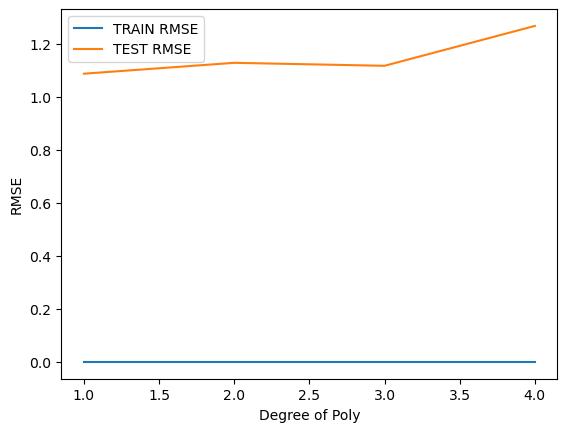

In [20]:
plt.plot(range(1,5),train_rmse_errors[:5],label='TRAIN RMSE')
plt.plot(range(1,5),test_rmse_errors[:5],label='TEST RMSE')

plt.xlabel('Degree of Poly')
plt.ylabel('RMSE')
plt.legend()

*Fit And Predict With DecisionTreeRegressor With GridSearchCV*

In [41]:
poly_converter=PolynomialFeatures(degree=2,include_bias=False)
from sklearn.model_selection import GridSearchCV
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=101)
poly_features=poly_converter.fit_transform(x_train)
x_test=poly_converter.transform(x_test)
scaler=StandardScaler()
poly_features=scaler.fit_transform(poly_features)
x_test=scaler.transform(x_test)
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'criterion': ['squared_error', 'absolute_error']
}

tree = DecisionTreeRegressor(random_state=42)

grid = GridSearchCV(
    estimator=tree,
    param_grid=param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

grid.fit(poly_features, y_train)

print("Best Parameters:")
print(grid.best_params_)

print("Best Score:")
print(grid.best_score_)
y_pred=grid.predict(x_test)
MAE=mean_absolute_error(y_test,y_pred)
MSE=mean_squared_error(y_test,y_pred)
RMSE=np.sqrt(MSE)
print("MAE : " , MAE)
print("MSE : " , MSE)
print("RMSE : " , RMSE)

Best Parameters:
{'criterion': 'squared_error', 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 20}
Best Score:
-0.9774988190285342
MAE :  0.8010738959095711
MSE :  1.03550691410886
RMSE :  1.017598601664163


*Use Regularization Methods(Ridge)*

In [42]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

ridge = Ridge()

param_grid = {
    'alpha': [0.001, 0.01, 0.1, 1, 10, 100]
}

ridge_grid = GridSearchCV(
    ridge,
    param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

ridge_grid.fit(poly_features, y_train)

print(ridge_grid.best_params_)


{'alpha': 100}


*Evaluate And Describe Your Conclusion With Ridge*

In [43]:
y_pred=ridge_grid.predict(x_test)
MAE=mean_absolute_error(y_test,y_pred)
MSE=mean_squared_error(y_test,y_pred)
RMSE=np.sqrt(MSE)
print("MAE : " , MAE)
print("MSE : " , MSE)
print("RMSE : " , RMSE)

MAE :  0.6997241916211862
MSE :  0.8155351831529175
RMSE :  0.9030698661526236


*Use Regularization Methods(Lasso)*

In [44]:
from sklearn.linear_model import Lasso

lasso = Lasso(max_iter=10000)

param_grid = {
    'alpha': [0.0001, 0.001, 0.01, 0.1, 1]
}

lasso_grid = GridSearchCV(
    lasso,
    param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

lasso_grid.fit(poly_features, y_train)

print(lasso_grid.best_params_)

{'alpha': 0.1}


*Evaluate And Describe Your Conclusion With Lasso*

In [45]:
y_pred=lasso_grid.predict(x_test)
MAE=mean_absolute_error(y_test,y_pred)
MSE=mean_squared_error(y_test,y_pred)
RMSE=np.sqrt(MSE)
print("MAE : " , MAE)
print("MSE : " , MSE)
print("RMSE : " , RMSE)

MAE :  0.6486056949284813
MSE :  0.68490044927317
RMSE :  0.8275871248836403


*Use Regularization Methods(Elastic Net)*

In [46]:
from sklearn.linear_model import ElasticNet

elastic = ElasticNet(max_iter=10000)

param_grid = {
    'alpha': [0.0001, 0.001, 0.01, 0.1, 1],
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
}

elastic_grid = GridSearchCV(
    elastic,
    param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

elastic_grid.fit(poly_features, y_train)

print(elastic_grid.best_params_)

{'alpha': 0.1, 'l1_ratio': 0.9}


*Evaluate And Describe Your Conclusion With Elastic Net*

In [47]:
y_pred=elastic_grid.predict(x_test)
MAE=mean_absolute_error(y_test,y_pred)
MSE=mean_squared_error(y_test,y_pred)
RMSE=np.sqrt(MSE)
print("MAE : " , MAE)
print("MSE : " , MSE)
print("RMSE : " , RMSE)

MAE :  0.6405680392934411
MSE :  0.6808326326069908
RMSE :  0.8251258283480106


*Use Regularization Methods(RidgeCV)*

In [48]:
from sklearn.linear_model import RidgeCV

ridgecv = RidgeCV(
    alphas=[0.001,0.01,0.1,1,10,100],
    cv=5
)

ridgecv.fit(poly_features, y_train)

print(ridgecv.alpha_)
y_pred=elastic_grid.predict(x_test)
MAE=mean_absolute_error(y_test,y_pred)
MSE=mean_squared_error(y_test,y_pred)
RMSE=np.sqrt(MSE)
print("MAE : " , MAE)
print("MSE : " , MSE)
print("RMSE : " , RMSE)

100.0
MAE :  0.6405680392934411
MSE :  0.6808326326069908
RMSE :  0.8251258283480106


*Use Regularization Methods(lassoCV)*

In [49]:
from sklearn.linear_model import LassoCV

lassocv = LassoCV(
    alphas=[0.0001,0.001,0.01,0.1,1],
    cv=5,
    max_iter=10000
)

lassocv.fit(poly_features, y_train)

print(lassocv.alpha_)
y_pred=elastic_grid.predict(x_test)
MAE=mean_absolute_error(y_test,y_pred)
MSE=mean_squared_error(y_test,y_pred)
RMSE=np.sqrt(MSE)
print("MAE : " , MAE)
print("MSE : " , MSE)
print("RMSE : " , RMSE)

c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.178e+00, tolerance: 4.990e-01
  model = cd_fast.enet_coordinate_descent(
c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.751e+00, tolerance: 5.141e-01
  model = cd_fast.enet_coordinate_descent(
c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.372e+00, toleranc

0.1
MAE :  0.6405680392934411
MSE :  0.6808326326069908
RMSE :  0.8251258283480106


c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.848e+00, tolerance: 5.174e-01
  model = cd_fast.enet_coordinate_descent(
